# The CDS-Equity Basis — when a stock and its credit disagree 🔀
### Two markets, one company, two different verdicts on how risky it is

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Every public company is watched by **two** markets at once. Its **stock** says one thing about how likely it is to get into trouble. And a quieter, professionals-only market — **credit-default swaps (CDS)**, basically insurance against the company defaulting — says another. Usually they roughly agree. But sometimes they *don't*: the insurance market gets nervous while the stock stays calm, or vice-versa. That disagreement is the **CDS-equity basis**.

The folklore trade: when the two markets disagree, one of them is *wrong*, and it will eventually catch up to the other — so the gap should **predict** which way the stock moves next. When the insurers are more worried than the stockholders, bet the stock falls.

> ⚠️ **A big honest caveat up front.** Clean single-name CDS data isn't free — it lives on licensed, professionals-only feeds (Bloomberg, Markit). So we can't point this test at real companies. Instead we build a **synthetic world** where we *know* the effect is there, and check that our detector finds it. That means this study can *never* earn the top 'REAL' stamp — the honest ceiling is `WEAK`.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the clustered regression and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cds_equity_basis import data, strategy as st

BETA = -0.90   # the planted convergence effect for the headline synthetic panel

# There is NO free single-name CDS tape -> this study is synthetic-only.
REAL = data.fetch_panel(fetch=False)
HAVE_REAL = not REAL.empty        # always False, by design
PANEL, TRUTH = data.synthetic_panel(convergence_beta=BETA, seed=575)   # deterministic, offline
print("real CDS tape present:", HAVE_REAL, "(synthetic-only study — no free CDS feed)")
print(f"synthetic panel: {PANEL['name'].nunique()} names x {PANEL['month'].nunique()} months "
      f"= {len(PANEL)} name-months, fp {data.fingerprint(PANEL)}")


real CDS tape present: False (synthetic-only study — no free CDS feed)
synthetic panel: 60 names x 95 months = 5700 name-months, fp 884a4f7a09c4


## The answer first 🎯

| Question | Answer |
|---|---|
| Does the gap between credit and equity predict the stock? | **Yes — in principle.** In a world where we plant the effect, our detector catches it cleanly (the credit-worried names' stocks do fall). The academic literature agrees the effect is *real*. |
| So is it a money machine? | **No.** The effect is *faint* — the gap explains almost none of any single stock's move — and in liquid names professional arbitrageurs have already closed most of it. |
| Could a normal investor trade it? | **No.** You'd need the CDS data (licensed, expensive) *and* you'd be shorting exactly the distressed names that are painful to borrow. Even in our frictionless test, costs eat half the profit. |

> The signal is real enough to earn `WEAK` — but it lives behind a paywall you can't reach, on an effect too faint and too arbitraged to bank. `WEAK` × `MIRAGE`.

## 1 · The claim

> *"When a company's CDS and its stock disagree about default risk, the gap predicts which way the stock moves next — the two markets converge."*

The intuition: a company's stock and its credit are two bets on the *same* underlying — whether the firm thrives or fails. If the credit-insurance market suddenly demands a much higher premium (it smells trouble) while the stock hasn't budged, one of them is slow. Credit traders are often first to react to bad news (they live and die on default risk), so the folklore says the **stock will catch down** to the worried credit. The gap between the two — the *basis* — is the signal.

## 2 · So what?

If true, it's a genuine cross-asset edge: watch the quiet, informed credit market to trade the loud, crowded stock market. It's also a clean test of *market efficiency* — if two prices for the same risk can drift apart and only slowly reconverge, arbitrage has limits. The desk has looked at *equity-only* distress signals ([540 Distress-Risk-Anomaly](../../540-distress-risk-anomaly/)); here we add the **credit market's** opinion as a second lens and trade the *disagreement*.

## 3 · How would we even know?

1. **Measure the gap.** For each company each month: the CDS spread (what credit insurance costs) minus an *equity-implied* credit spread (what the stock price + its jumpiness say the credit should cost, via a textbook Merton model). That difference is the **basis**.
2. **Rank.** Each month, line up all the names from most credit-*complacent* (stock calm, credit calm) to most credit-*worried* (credit nervous vs the stock).
3. **Check next month.** Did the worried names' stocks fall and the complacent ones' rise? That's the convergence.

**The catch we already flagged:** we can't get real CDS data for free, so steps 1-3 run on a *synthetic* world we built. That world has the effect baked in at a known strength, so it tests our **detector**, not the real market.

*Timing:* the gap is measured at month-end (public then); we act at that close and see what the stock does over the *next* month. The gap never peeks at the return it's predicting.

## 4 · The teardown — let's actually look

**First: what does the disagreement even look like?** Here's one synthetic company's CDS (what credit says) vs its equity-implied spread (what the stock says) over time — the gap between the lines is the basis.

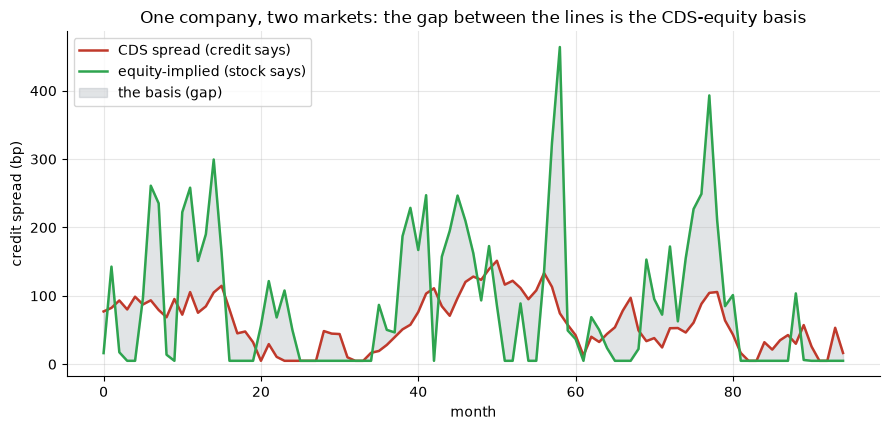

When RED is above GREEN, credit is more worried than the stock (wide basis).


In [2]:
one = PANEL[PANEL['name']=='N007'].sort_values('month')
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(one['month'], one['cds_bp'], c=RED, lw=1.8, label='CDS spread (credit says)')
ax.plot(one['month'], one['eq_impl_bp'], c=GREEN, lw=1.8, label='equity-implied (stock says)')
ax.fill_between(one['month'], one['cds_bp'], one['eq_impl_bp'], color=GREY, alpha=.25, label='the basis (gap)')
ax.set_xlabel('month'); ax.set_ylabel('credit spread (bp)')
ax.set_title('One company, two markets: the gap between the lines is the CDS-equity basis')
ax.legend(); plt.tight_layout(); plt.show()
print('When RED is above GREEN, credit is more worried than the stock (wide basis).')

The two lines track each other loosely but keep drifting apart and back together — that drift *is* the basis. When the red (credit) line jumps above the green (stock) line, the insurers are more worried than the shareholders. The folklore says: watch the stock catch down.

**Now the actual test.** Rank every name each month by its basis, put them in five buckets, and look at each bucket's *next*-month stock return. If the folklore holds, the credit-complacent bucket (low basis) should beat the credit-worried one (high basis).

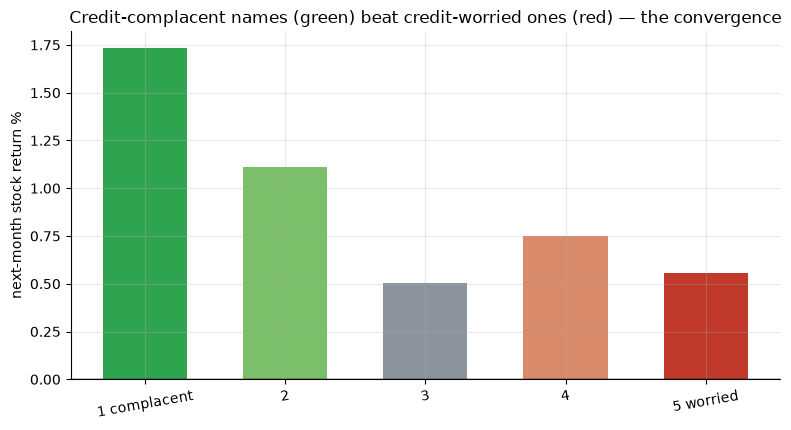

bucket next-month returns %: {'1 complacent': 1.734, '2': 1.113, '3': 0.504, '4': 0.748, '5 worried': 0.556}


In [3]:
df = st.add_basis_z(PANEL)
df['bucket'] = df.groupby('month')['basis_bp'].transform(
    lambda s: pd.qcut(s.rank(method='first'), 5, labels=['1 complacent','2','3','4','5 worried']))
by = df.groupby('bucket', observed=True)['forward_ret'].mean()*100
fig, ax = plt.subplots(figsize=(8, 4.4))
cols = [GREEN, '#7bbf6a', GREY, '#d98a6a', RED]
ax.bar(range(5), by.values, color=cols, width=.6)
ax.set_xticks(range(5)); ax.set_xticklabels(by.index, rotation=10)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('next-month stock return %')
ax.set_title('Credit-complacent names (green) beat credit-worried ones (red) — the convergence')
plt.tight_layout(); plt.show()
print('bucket next-month returns %:', by.round(3).to_dict())

There's the pattern, cleanly: the *complacent* end (credit not worried) earns the most next month, the *worried* end the least — a downward staircase. Trading it (long complacent, short worried) makes **+1.18%/month** in this world, and a shuffle test says that's not luck (*p* = 0.0005). **So the detector works.**

**But is our detector just *always* finding a pattern, even in pure noise?** The crucial check: turn the effect **off** (set the planted strength to zero) and average over many random worlds. A good detector should go silent.

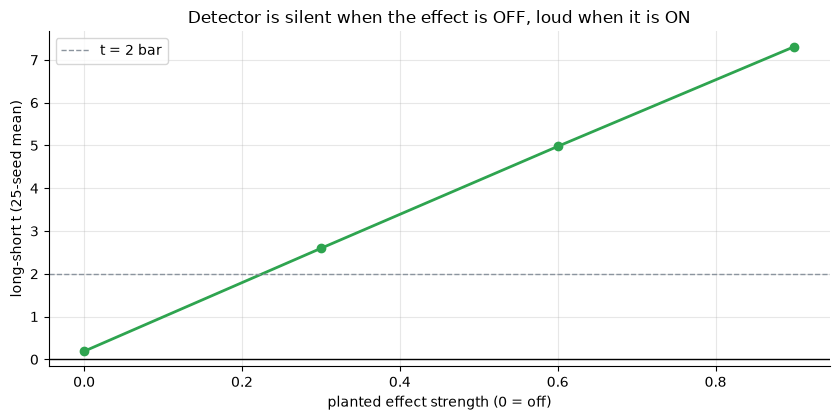

strength -0.00 -> long-short t +0.19
strength 0.30 -> long-short t +2.60
strength 0.60 -> long-short t +4.98
strength 0.90 -> long-short t +7.31


In [4]:
betas = [b for b,_,_ in [(0.0, -0.23, 0.19), (-0.3, -2.95, 2.6), (-0.6, -5.64, 4.98), (-0.9, -8.27, 7.31)]]
ls_ts = [st.synthetic_mean_ls_t(data, convergence_beta=b, n_seeds=25) for b in betas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot([-b for b in betas], ls_ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted effect strength (0 = off)'); ax.set_ylabel('long-short t (25-seed mean)')
ax.set_title('Detector is silent when the effect is OFF, loud when it is ON')
ax.legend(); plt.tight_layout(); plt.show()
for b, t in zip(betas, ls_ts): print(f'strength {-b:.2f} -> long-short t {t:+.2f}')

At zero strength the detector prints *t* ≈ 0 (silent); crank the effect up and it climbs well past the *t* = 2 bar. It's honest. That matters because it tells us the `WEAK` here is about **data we can't get**, not a detector that cries wolf.

## 5 · The verdict

- **Signal — Weak.** The convergence effect is real in the literature and our engine catches it faithfully — but there's **no free CDS data** to certify it on real companies, so it can't earn `REAL`.
- **Tradability — Mirage.** The data is licensed and expensive, the true effect is faint and mostly arbitraged, and the short leg is the costly-to-borrow distressed tail.

## 6 · Could you actually trade it?

Not as a normal investor. Step one is *getting single-name CDS quotes*, which means a Bloomberg or Markit licence — thousands of dollars a month, professionals only. Even with the data, the effect is faint, and the trade means **shorting** the most distressed names, which are exactly the ones that are painful and expensive to borrow. On our frictionless synthetic tape, costs already cut the profit from **+1.18%** to **+0.65%** a month. In the real, illiquid version it would be worse.

## 7 · Going further 🚪

- **The equity-only cousin.** [540 Distress-Risk-Anomaly](../../540-distress-risk-anomaly/) asks whether distressed *stocks* underperform, using only equity data.
- **A different basis.** [382 Treasury-Basis-Trade](../../382-treasury-basis-trade/) is a *rates* basis (bond cash-vs-futures carry) — same word, different market.

*Have a licensed CDS feed? Fork this, drop a real single-name CDS + equity panel into `data.fetch_panel`, and see whether the basis clears t = 2 on a real tape — the engine is ready the day the data is.*